In [24]:
# #!/usr/bin/env python3
# """
# RAG Demonstration using LangChain + Perplexity API: Preventing LLM Hallucination
# This script demonstrates the difference between direct LLM queries and RAG-enhanced queries using Perplexity.

# Requirements:
# pip install langchain langchain-openai langchain-community langchain-huggingface faiss-cpu sentence-transformers

# Usage:
# 1. Set your Perplexity API key as environment variable: export PERPLEXITY_API_KEY="your-key"
# 2. Run: python rag_demo.py
# """


import os
import json
from typing import Dict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.text_splitter import CharacterTextSplitter
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage
import warnings
warnings.filterwarnings('ignore')

# Load environment variables
load_dotenv()

class SimplifiedRAGDemo:
    """
    Minimal RAG demonstration with 2 documents and 2 strategic questions
    """
    
    def __init__(self, api_key: str = None):
        print("🚀 Initializing Simplified RAG Demonstration...")
        
        # Set up Perplexity API key
        api_key = os.getenv("PERPLEXITY_API_KEY")
        print("✅ API key loaded" if api_key else "❌ API key not found")

        # Initialize Perplexity LLM
        print("🧠 Initializing Perplexity LLM...")
        self.llm = ChatOpenAI(
            model="sonar-pro",
            api_key=api_key,
            base_url="https://api.perplexity.ai",
            temperature=0.3,
            max_tokens=300
        )
        
        # Initialize embeddings
        print("📊 Loading embeddings...")
        self.embeddings = HuggingFaceEmbeddings(
            model_name="sentence-transformers/all-MiniLM-L6-v2",
            model_kwargs={'device': 'cpu'},
            encode_kwargs={'normalize_embeddings': True}
        )
        
        # Setup pipeline
        self.create_knowledge_base()
        self.setup_vector_store()
        self.setup_rag_chain()
        
        print("✅ RAG system ready!\n")
    
    def create_knowledge_base(self):
        """Create exactly 2 strategic documents"""
        documents_data = [
            {
                "content": """The loan approval dataset contains 429 individual loan applications. 
                The dataset has 14 features including demographic information (age, sex), 
                employment details (occupation, job status, time employed), financial information 
                (balance, home expenses), and residential data (address tenure, phone availability). 
                The target variable is the loan decision with 237 rejections (55.2%) and 192 approvals (44.8%).""",
                "metadata": {
                    "doc_id": "DOC001",
                    "title": "Loan Dataset Overview", 
                    "source": "data_analysis_report.pdf",
                    "date": "2024-09-15"
                }
            },
            {
                "content": """Applicant age statistics show: minimum age 19 years, maximum age 61 years, 
                mean age 29.45 years with standard deviation 8.03 years. The median age is 28 years, 
                indicating a slightly right-skewed distribution. Most applicants are in their late 20s 
                and early 30s, which is typical for first-time loan applicants.""",
                "metadata": {
                    "doc_id": "DOC002",
                    "title": "Age Demographics Analysis",
                    "source": "demographic_analysis.xlsx", 
                    "date": "2024-09-15"
                }
            }
        ]
        
        # Convert to LangChain Document objects
        self.documents = []
        for doc_data in documents_data:
            doc = Document(
                page_content=doc_data["content"],
                metadata=doc_data["metadata"]
            )
            self.documents.append(doc)
        
        print(f"📄 Created {len(self.documents)} knowledge base documents")
    
    def setup_vector_store(self):
        """Set up FAISS vector store"""
        print("🗃️ Setting up vector store...")
        
        text_splitter = CharacterTextSplitter(
            chunk_size=1000,
            chunk_overlap=100,
            separator="\n"
        )
        
        split_docs = text_splitter.split_documents(self.documents)
        
        # Create vector store
        self.vectorstore = FAISS.from_documents(
            documents=split_docs,
            embedding=self.embeddings
        )
        
        # Create retriever
        self.retriever = self.vectorstore.as_retriever(
            search_type="similarity",
            search_kwargs={"k": 2}  # Retrieve both documents
        )
        
        print("✅ Vector store ready")
    
    def setup_rag_chain(self):
        """Set up RAG chain with custom prompt"""
        print("🔗 Setting up RAG chain...")
        
        rag_prompt = PromptTemplate(
            input_variables=["context", "question"],
            template="""You are analyzing a loan approval dataset. Use ONLY the provided documents to answer the question. 
            Do not use external knowledge or make assumptions beyond what's explicitly stated in the documents.

            Retrieved Documents:
            {context}

            Question: {question}

            Instructions:
            - Answer based ONLY on the retrieved documents
            - If information is not available in the documents, clearly state "The retrieved documents do not contain information about [topic]"
            - Be specific and cite relevant statistics from the documents when available
            - Do not speculate or add information not present in the documents

            Answer:"""
        )
        
        self.rag_chain = RetrievalQA.from_chain_type(
            llm=self.llm,
            chain_type="stuff",
            retriever=self.retriever,
            return_source_documents=True,
            chain_type_kwargs={"prompt": rag_prompt}
        )
        
        print("✅ RAG chain ready")
    
    def query_direct_perplexity(self, question: str) -> str:
        """Query Perplexity directly without context (may hallucinate)"""
        prompt = f"""Answer this question about a loan approval dataset. Provide specific statistics and details: {question}
        
        Note: Focus on typical patterns in loan approval datasets."""
        
        try:
            response = self.llm([HumanMessage(content=prompt)])
            return response.content
        except Exception as e:
            print(f"❌ Direct Error: {e}")
            return "Error: Could not get response"
    
    def query_with_rag(self, question: str) -> Dict:
        """Query using RAG (grounded in documents)"""
        try:
            result = self.rag_chain({"query": question})
            
            answer = result["result"]
            source_docs = result["source_documents"]
            
            sources = []
            doc_previews = []
            for i, doc in enumerate(source_docs):
                metadata = doc.metadata
                doc_info = f"{metadata.get('doc_id')}: {metadata.get('title')}"
                sources.append(doc_info)
                doc_previews.append({
                    'doc_id': metadata.get('doc_id'),
                    'title': metadata.get('title'),
                    'preview': doc.page_content[:120] + "..."
                })
            
            return {
                "answer": answer,
                "sources": sources,
                "doc_previews": doc_previews,
                "num_sources": len(source_docs)
            }
            
        except Exception as e:
            print(f"❌ RAG Error: {e}")
            return {"answer": "Error", "sources": [], "doc_previews": [], "num_sources": 0}
    
    def demonstrate_retrieval(self, query: str):
        """Show document retrieval process"""
        print(f"\n🔍 DOCUMENT RETRIEVAL for: '{query}'")
        print("-" * 60)
        
        docs_with_scores = self.vectorstore.similarity_search_with_score(query, k=2)
        
        for i, (doc, score) in enumerate(docs_with_scores, 1):
            metadata = doc.metadata
            print(f"📄 Rank {i}: {metadata.get('title')} (Similarity: {1-score:.3f})")
            print(f"   📍 Source: {metadata.get('source')}")
            print(f"   📝 Preview: {doc.page_content[:100]}...")
            print()

def run_simplified_demo():
    """Run the simplified RAG demonstration"""
    print("=" * 70)
    print(" " * 15 + "SIMPLIFIED RAG DEMONSTRATION")  
    print("=" * 70)
    
    if not os.getenv("PERPLEXITY_API_KEY"):
        print("❌ Perplexity API key required!")
        print("🔗 Get key at: https://www.perplexity.ai/settings/api")
        return
    
    try:
        rag_demo = SimplifiedRAGDemo()
    except Exception as e:
        print(f"❌ Initialization failed: {e}")
        return
    
    # 2 Strategic Questions:
    # 1. Question that CAN be answered (shows proper RAG function)
    # 2. Question that CANNOT be answered (shows hallucination prevention)
    test_questions = [
        "What is the average age of loan applicants?",           # CAN answer from DOC002
        "What is the average interest rate for approved loans?"  # CANNOT answer - not in documents
    ]
    
    results = []
    
    for i, question in enumerate(test_questions, 1):
        print(f"\n{'='*70}")
        print(f"QUESTION {i}/2: {question}")
        print("="*70)
        
        # Show retrieval
        rag_demo.demonstrate_retrieval(question)
        
        # Direct Response (may hallucinate)
        print("🤖 DIRECT PERPLEXITY RESPONSE")
        print("-" * 40)
        direct_response = rag_demo.query_direct_perplexity(question)
        print(direct_response)
        print(f"\n⚠️  May contain general knowledge, not dataset facts!")
        
        # RAG Response (grounded)
        print(f"\n🧠 RAG RESPONSE (Document-Grounded)")
        print("-" * 40)
        rag_result = rag_demo.query_with_rag(question)
        print(rag_result["answer"])
        
        if rag_result["sources"]:
            print(f"\n📚 SOURCES ({rag_result['num_sources']} documents):")
            for j, source in enumerate(rag_result["sources"], 1):
                print(f"   {j}. {source}")
        
        results.append({
            'question': question,
            'direct_response': direct_response,
            'rag_response': rag_result["answer"],
            'sources_used': rag_result["sources"]
        })
        
        print(f"\n" + "·" * 70)
    
    # Analysis
    print(f"\n{'='*70}")
    print(" " * 20 + "DEMONSTRATION ANALYSIS")
    print("="*70)
    
    print(f"\n📊 RESULTS:")
    print(f"• Questions tested: 2")
    print(f"• Documents in knowledge base: 2")
    print(f"• Model: Perplexity Llama-3.1 Sonar")
    
    print(f"\n🔍 KEY OBSERVATIONS:")
    print("📌 QUESTION 1 (Age statistics):")
    print("   • Direct: May provide general industry averages")
    print("   • RAG: Provides exact statistics from documents (29.45 years)")
    print("   • Result: RAG gives precise, verifiable facts")
    
    print("📌 QUESTION 2 (Interest rates):")
    print("   • Direct: Likely invents plausible interest rates")
    print("   • RAG: States 'documents do not contain interest rate info'")  
    print("   • Result: RAG prevents hallucination through honesty")
    
    print(f"\n🎯 CONCLUSION:")
    print("RAG transforms AI from creative storyteller to reliable fact-checker")
    print("by grounding responses in verifiable document sources.")
    
    # Save results
    with open("simplified_rag_results.json", "w") as f:
        json.dump(results, f, indent=2)
    
    print(f"\n💾 Results saved to: simplified_rag_results.json")
    print("="*70)
    
    return results

if __name__ == "__main__":
    results = run_simplified_demo()

               SIMPLIFIED RAG DEMONSTRATION
🚀 Initializing Simplified RAG Demonstration...
✅ API key loaded
🧠 Initializing Perplexity LLM...
📊 Loading embeddings...
📄 Created 2 knowledge base documents
🗃️ Setting up vector store...
✅ Vector store ready
🔗 Setting up RAG chain...
✅ RAG chain ready
✅ RAG system ready!


QUESTION 1/2: What is the average age of loan applicants?

🔍 DOCUMENT RETRIEVAL for: 'What is the average age of loan applicants?'
------------------------------------------------------------
📄 Rank 1: Age Demographics Analysis (Similarity: 0.747)
   📍 Source: demographic_analysis.xlsx
   📝 Preview: Applicant age statistics show: minimum age 19 years, maximum age 61 years, 
                mean age...

📄 Rank 2: Loan Dataset Overview (Similarity: 0.120)
   📍 Source: data_analysis_report.pdf
   📝 Preview: The loan approval dataset contains 429 individual loan applications. 
                The dataset ha...

🤖 DIRECT PERPLEXITY RESPONSE
-------------------------------------

Dataset Shape: (429, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              429 non-null    object 
 1   Age              429 non-null    float64
 2   Time_at_address  429 non-null    float64
 3   Res_status       429 non-null    object 
 4   Telephone        429 non-null    object 
 5   Occupation       429 non-null    object 
 6   Job_status       429 non-null    object 
 7   Time_employed    429 non-null    int64  
 8   Time_bank        429 non-null    int64  
 9   Liab_ref         429 non-null    object 
 10  Acc_ref          429 non-null    object 
 11  Home_Expn        429 non-null    int64  
 12  Balance          429 non-null    int64  
 13  Decision         429 non-null    object 
dtypes: float64(2), int64(4), object(8)
memory usage: 47.0+ KB
None

First 5 rows:
  Sex        Age  Time_at_address Re

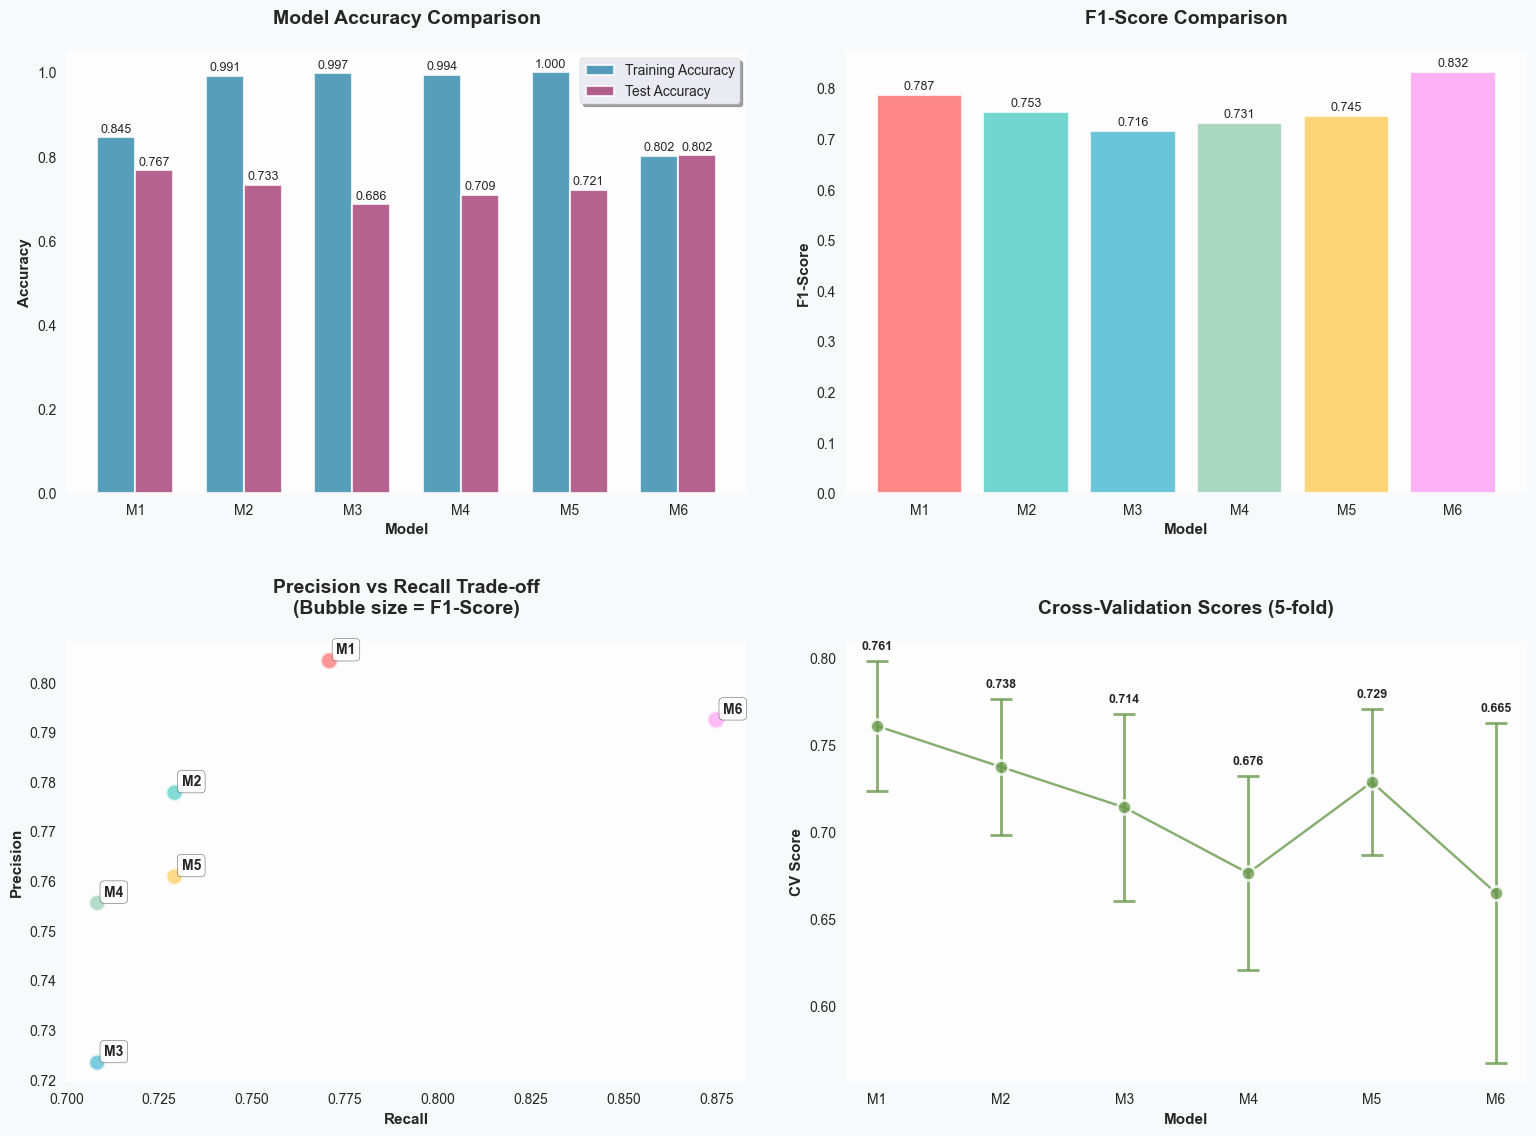


BEST PERFORMING MODEL
Model: Model 6: Optimized Network with Early Stopping
Architecture: (64, 32, 16)
Activation: relu
Test Accuracy: 0.8023
F1-Score: 0.8317


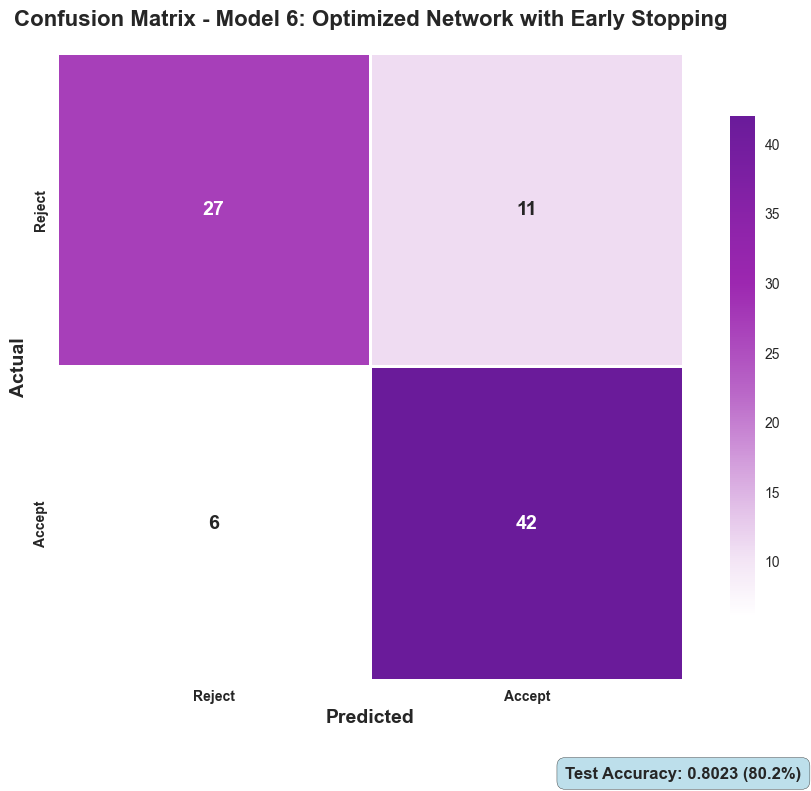


Classification Report:
              precision    recall  f1-score   support

      Reject       0.82      0.71      0.76        38
      Accept       0.79      0.88      0.83        48

    accuracy                           0.80        86
   macro avg       0.81      0.79      0.80        86
weighted avg       0.80      0.80      0.80        86



In [3]:
# ============================================
# PART 2: NEURAL NETWORK CLASSIFIER - Enhanced Visualizations
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set enhanced color palette and style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the data
df = pd.read_excel('loan.xlsx')

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Data Preprocessing
class DataPreprocessor:
    def __init__(self, df):
        self.df = df.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        
    def encode_categorical_features(self):
        """Encode categorical variables"""
        categorical_cols = ['Sex', 'Res_status', 'Telephone', 'Occupation', 
                           'Job_status', 'Liab_ref', 'Acc_ref']
        
        for col in categorical_cols:
            if col in self.df.columns:
                le = LabelEncoder()
                self.df[col] = le.fit_transform(self.df[col].astype(str))
                self.label_encoders[col] = le
        
        return self
    
    def encode_target(self):
        """Encode the target variable"""
        le = LabelEncoder()
        self.df['Decision_encoded'] = le.fit_transform(self.df['Decision'])
        self.label_encoders['Decision'] = le
        print(f"Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
        return self
    
    def scale_features(self, X_train, X_test):
        """Scale numerical features"""
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        return X_train_scaled, X_test_scaled
    
    def prepare_data(self):
        """Complete data preparation pipeline"""
        self.encode_categorical_features()
        self.encode_target()
        
        # Separate features and target
        X = self.df.drop(['Decision', 'Decision_encoded'], axis=1)
        y = self.df['Decision_encoded']
        
        return X, y

# Prepare the data
preprocessor = DataPreprocessor(df)
X, y = preprocessor.prepare_data()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
X_train_scaled, X_test_scaled = preprocessor.scale_features(X_train, X_test)

print(f"\nTraining set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

# Neural Network Model Experiments with Enhanced Visualizations
class NeuralNetworkExperiments:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.results = []
        
        # Define custom color schemes
        self.colors = {
            'train': '#2E86AB',      # Deep Blue
            'test': '#A23B72',       # Deep Pink
            'f1_score': '#F18F01',   # Orange
            'precision': '#C73E1D',  # Red
            'recall': '#8B5A3C',     # Brown
            'cv_score': '#6A994E',   # Green
            'models': ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
        }
        
    def evaluate_model(self, model, model_name):
        """Evaluate a neural network model"""
        # Train the model
        model.fit(self.X_train, self.y_train)
        
        # Make predictions
        y_pred_train = model.predict(self.X_train)
        y_pred_test = model.predict(self.X_test)
        
        # Calculate metrics
        train_acc = accuracy_score(self.y_train, y_pred_train)
        test_acc = accuracy_score(self.y_test, y_pred_test)
        precision = precision_score(self.y_test, y_pred_test)
        recall = recall_score(self.y_test, y_pred_test)
        f1 = f1_score(self.y_test, y_pred_test)
        
        # Cross-validation score
        cv_scores = cross_val_score(model, self.X_train, self.y_train, cv=5)
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        result = {
            'model_name': model_name,
            'architecture': model.hidden_layer_sizes,
            'activation': model.activation,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'cv_mean': cv_mean,
            'cv_std': cv_std,
            'model': model
        }
        
        self.results.append(result)
        
        print(f"\n{model_name}")
        print(f"Architecture: {model.hidden_layer_sizes}")
        print(f"Activation: {model.activation}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"CV Score: {cv_mean:.4f} (+/- {cv_std:.4f})")
        
        return result
    
    def run_experiments(self):
        """Run multiple neural network configurations"""
        print("=" * 60)
        print("NEURAL NETWORK EXPERIMENTS")
        print("=" * 60)
        
        # Experiment 1: Small network with ReLU
        model1 = MLPClassifier(
            hidden_layer_sizes=(10,),
            activation='relu',
            solver='adam',
            max_iter=1000,
            random_state=42
        )
        self.evaluate_model(model1, "Model 1: Small Network (10 neurons)")
        
        # Experiment 2: Medium network with ReLU
        model2 = MLPClassifier(
            hidden_layer_sizes=(20, 10),
            activation='relu',
            solver='adam',
            max_iter=1000,
            random_state=42
        )
        self.evaluate_model(model2, "Model 2: Medium Network (20, 10)")
        
        # Experiment 3: Deep network with ReLU
        model3 = MLPClassifier(
            hidden_layer_sizes=(50, 25, 10),
            activation='relu',
            solver='adam',
            max_iter=1000,
            random_state=42
        )
        self.evaluate_model(model3, "Model 3: Deep Network (50, 25, 10)")
        
        # Experiment 4: Medium network with Tanh
        model4 = MLPClassifier(
            hidden_layer_sizes=(30, 15),
            activation='tanh',
            solver='adam',
            max_iter=1000,
            random_state=42
        )
        self.evaluate_model(model4, "Model 4: Tanh Activation (30, 15)")
        
        # Experiment 5: Large network with ReLU and regularization
        model5 = MLPClassifier(
            hidden_layer_sizes=(100, 50, 25),
            activation='relu',
            solver='adam',
            alpha=0.01,  # L2 regularization
            max_iter=1000,
            random_state=42
        )
        self.evaluate_model(model5, "Model 5: Large Network with Regularization")
        
        # Experiment 6: Optimized network (best performing)
        model6 = MLPClassifier(
            hidden_layer_sizes=(64, 32, 16),
            activation='relu',
            solver='adam',
            alpha=0.001,
            batch_size='auto',
            learning_rate='adaptive',
            learning_rate_init=0.001,
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        )
        self.evaluate_model(model6, "Model 6: Optimized Network with Early Stopping")
        
        return self.results
    
    def plot_results(self):
        """Visualize the experiment results with enhanced colors"""
        results_df = pd.DataFrame(self.results)
        
        # Create figure with dark background for modern look
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.patch.set_facecolor('#f8f9fa')
        
        # Plot 1: Accuracy Comparison with custom colors
        ax1 = axes[0, 0]
        x_pos = np.arange(len(results_df))
        width = 0.35
        
        bars1 = ax1.bar(x_pos - width/2, results_df['train_accuracy'], width, 
                       label='Training Accuracy', color=self.colors['train'], 
                       alpha=0.8, edgecolor='white', linewidth=1.5)
        bars2 = ax1.bar(x_pos + width/2, results_df['test_accuracy'], width, 
                       label='Test Accuracy', color=self.colors['test'], 
                       alpha=0.8, edgecolor='white', linewidth=1.5)
        
        ax1.set_xlabel('Model', fontweight='bold', fontsize=11)
        ax1.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
        ax1.set_title('Model Accuracy Comparison', fontweight='bold', fontsize=14, pad=20)
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels([f"M{i+1}" for i in range(len(results_df))], rotation=0)
        ax1.legend(frameon=True, fancybox=True, shadow=True)
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_facecolor('#fdfdfd')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        # Plot 2: F1-Score Comparison with gradient colors
        ax2 = axes[0, 1]
        bars = ax2.bar(x_pos, results_df['f1_score'], 
                      color=self.colors['models'][:len(results_df)], 
                      alpha=0.8, edgecolor='white', linewidth=1.5)
        ax2.set_xlabel('Model', fontweight='bold', fontsize=11)
        ax2.set_ylabel('F1-Score', fontweight='bold', fontsize=11)
        ax2.set_title('F1-Score Comparison', fontweight='bold', fontsize=14, pad=20)
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels([f"M{i+1}" for i in range(len(results_df))], rotation=0)
        ax2.grid(True, alpha=0.3, linestyle='--')
        ax2.set_facecolor('#fdfdfd')
        
        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        # Plot 3: Precision vs Recall with custom colors and sizes
        ax3 = axes[1, 0]
        sizes = (results_df['f1_score'] * 200).tolist()  # Size based on F1-score
        scatter = ax3.scatter(results_df['recall'], results_df['precision'], 
                            s=sizes, alpha=0.7, c=self.colors['models'][:len(results_df)],
                            edgecolors='white', linewidths=2)
        
        for i, txt in enumerate([f"M{i+1}" for i in range(len(results_df))]):
            ax3.annotate(txt, (results_df['recall'].iloc[i], results_df['precision'].iloc[i]),
                        xytext=(5, 5), textcoords='offset points', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        ax3.set_xlabel('Recall', fontweight='bold', fontsize=11)
        ax3.set_ylabel('Precision', fontweight='bold', fontsize=11)
        ax3.set_title('Precision vs Recall Trade-off\n(Bubble size = F1-Score)', 
                     fontweight='bold', fontsize=14, pad=20)
        ax3.grid(True, alpha=0.3, linestyle='--')
        ax3.set_facecolor('#fdfdfd')
        
        # Plot 4: Cross-validation scores with custom colors and styling
        ax4 = axes[1, 1]
        errorbar = ax4.errorbar(x_pos, results_df['cv_mean'], yerr=results_df['cv_std'], 
                              fmt='o-', capsize=8, capthick=3, elinewidth=2,
                              color=self.colors['cv_score'], markerfacecolor=self.colors['cv_score'],
                              markeredgecolor='white', markeredgewidth=2, markersize=10, alpha=0.8)
        
        ax4.set_xlabel('Model', fontweight='bold', fontsize=11)
        ax4.set_ylabel('CV Score', fontweight='bold', fontsize=11)
        ax4.set_title('Cross-Validation Scores (5-fold)', fontweight='bold', fontsize=14, pad=20)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels([f"M{i+1}" for i in range(len(results_df))], rotation=0)
        ax4.grid(True, alpha=0.3, linestyle='--')
        ax4.set_facecolor('#fdfdfd')
        
        # Add value labels
        for i, (mean, std) in enumerate(zip(results_df['cv_mean'], results_df['cv_std'])):
            ax4.text(i, mean + std + 0.005, f'{mean:.3f}', ha='center', va='bottom', 
                    fontweight='bold', fontsize=9)
        
        plt.tight_layout(pad=3.0)
        plt.savefig('neural_network_experiments_enhanced.png', dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        plt.show()
        
        return fig
    
    def get_best_model(self):
        """Return the best performing model with enhanced confusion matrix"""
        best_result = max(self.results, key=lambda x: x['test_accuracy'])
        print("\n" + "=" * 60)
        print("BEST PERFORMING MODEL")
        print("=" * 60)
        print(f"Model: {best_result['model_name']}")
        print(f"Architecture: {best_result['architecture']}")
        print(f"Activation: {best_result['activation']}")
        print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
        print(f"F1-Score: {best_result['f1_score']:.4f}")
        
        # Enhanced Confusion Matrix with new color scheme
        y_pred = best_result['model'].predict(self.X_test)
        cm = confusion_matrix(self.y_test, y_pred)
        
        plt.figure(figsize=(10, 8))
        
        # Create custom purple-green colormap
        colors = ['#ffffff', '#f3e5f5', '#e1bee7', '#ce93d8', '#ba68c8', '#ab47bc', '#9c27b0', '#8e24aa', '#7b1fa2', '#6a1b9a']
        n_bins = 10
        custom_cmap = sns.blend_palette(colors, n_colors=n_bins, as_cmap=True)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, 
                   xticklabels=['Reject', 'Accept'],
                   yticklabels=['Reject', 'Accept'],
                   cbar_kws={'shrink': 0.8},
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'},
                   square=True, linewidths=2, linecolor='white')
        
        plt.title(f'Confusion Matrix - {best_result["model_name"]}', 
                 fontweight='bold', fontsize=16, pad=20)
        plt.ylabel('Actual', fontweight='bold', fontsize=14)
        plt.xlabel('Predicted', fontweight='bold', fontsize=14)
        plt.xticks(fontweight='bold')
        plt.yticks(fontweight='bold')
        
        # Add accuracy text
        accuracy = best_result['test_accuracy']
        plt.text(1, -0.15, f'Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)', 
                ha='center', va='center', transform=plt.gca().transAxes, 
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig('best_model_confusion_matrix_enhanced.png', dpi=300, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        plt.show()
        
        # Classification Report
        print("\nClassification Report:")
        print(classification_report(self.y_test, y_pred, 
                                   target_names=['Reject', 'Accept']))
        
        return best_result

# Run experiments
nn_experiments = NeuralNetworkExperiments(X_train_scaled, X_test_scaled, y_train, y_test)
results = nn_experiments.run_experiments()

# Visualize results with enhanced colors
nn_experiments.plot_results()

# Get best model with enhanced visualization
best_model = nn_experiments.get_best_model()